# Transformers vs statistical dependence models: the widened backtest

Head-to-head comparison of the gallery on the Meyers retrospective protocol
(train on the upper triangle as of **1997-12-31**, score realized ultimates
from later diagonals). Third revision of this study; the design changed
materially on 2026-07-08.

**Study design.** Companies passing the monograph's Table A.1 screens on
**≥2 of the four** Schedule P lines, each scored on exactly its passing
lines: **60 companies, 152 (company, line) cells** — up from 6 companies /
24 cells (kept as `*_v2_sixcompany.csv`). Every model sees identical cohort
data: the transformers train on precisely the scored (company, line) pairs —
no monoline data (the pool comparisons showed looser pools also *hurt*:
`experiment_v3_screened.csv`, `experiment_v3_market.csv`). Every row
carries `anchor` (loss-to-date at as_of) and `premium`, enabling
**reserve-basis, distribution-free** point evaluation alongside CRPS/KS.

| entry | dependence mechanism | fit shape |
|---|---|---|
| `chain_ladder` | none — point benchmark | volume-weighted CL per (company, line) |
| `sur` | cross-line error covariance per dev transition (Zhang 2010 FGLS) | per company, screened lines jointly |
| `copula_glm` | Gaussian copula across lines per cell (Shi & Frees 2011) | per company, screened lines jointly |
| `nn_transformer` | none — single-line cohorts, independent draws across lines | one pooled fit, per-(company, line) predicts |
| `nn_ml_ar` | attention across lines + within-diagonal line-by-line AR sampling | one pooled company fit, per-company predicts |
| `nn_ml_joint` | attention across lines + multivariate Gaussian-mixture head per cell | one pooled company fit, per-company predicts |

**Transformer version: v3** — pinned per-dev standardization (v2; replaced
the inherit-earlier-dev tail stats that broke v1) plus **relative calendar
encoding** (distance past the conditioning cutoff — absolute learned
calendar positions are untrained exactly where forecasts live). The
`nn_ml_*` entries are the research contribution: one encoder attends over
every (line, origin, dev) cell of a company, and `config.dependence` picks
how cross-line dependence reaches the draws.

Headline field is **paid_loss** (the copula's lognormal marginals cannot
take negative reported increments). Produced by
`scripts/compare_gallery.py`; this notebook only analyzes the committed
artifacts.

In [1]:
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from ibnr.kernels.calibration import ks_uniformity, pp_points

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

RESULTS = Path("results/compare_gallery.csv")
df = pd.read_csv(RESULTS, dtype={"company_code": str})
MODELS = ["sur", "copula_glm", "nn_transformer", "nn_ml_ar", "nn_ml_joint"]  # distributional
POINT_MODELS = ["chain_ladder", *MODELS]
LINES = sorted(df.loc[df["line"] != "ALL", "line"].unique())

print(f"data publish: {df['mart_publish_id'].iloc[0]}   loss field: {df['loss_field'].iloc[0]}")
n_cells = len(df[(df["model"] == "chain_ladder") & (df["line"] != "ALL")])
print(f"{df['company_code'].nunique()} companies, {n_cells} scored (company, line) cells")
failed = df[df["error"].notna()] if "error" in df else pd.DataFrame()
if len(failed):
    print("failed fits:")
    print(failed.groupby("model")["error"].agg(["count", "first"]).to_string())

data publish: 20260613_041006   loss field: paid_loss
60 companies, 152 scored (company, line) cells
failed fits:
       count                                                                                             first
model                                                                                                         
sur        2  non-positive cumulative 'paid_loss' cells; the 1/C variance weighting needs positive cumulatives


## Results table

One row per (model, line, company): predictive mean of the line-total
ultimate, spread, realized outcome, the outcome's percentile in the
predictive distribution, CRPS, plus `anchor` (loss-to-date at as_of) and
`premium`. `line == "ALL"` rows are the multiline models' *diversified
grand totals* — sums across lines inside the same draws. `chain_ladder`
rows carry the point estimate only (no distribution by construction).

In [2]:
ok = df[df["percentile"].notna() & (df["line"] != "ALL")].copy()
ok["err_pct"] = (ok["estimate"] - ok["outcome"]) / ok["outcome"] * 100
display_cols = [
    "model",
    "line",
    "company_code",
    "estimate",
    "outcome",
    "err_pct",
    "cv",
    "percentile",
    "crps",
]
ok[display_cols].sort_values(["line", "company_code", "model"]).round(2)

,model,line,company_code,estimate,outcome,err_pct,cv,percentile,crps
420,copula_glm,commercial_auto,10022,6307.17,5829.0,8.20,0.12,26.13,200.06
784,nn_ml_ar,commercial_auto,10022,6206.26,5829.0,6.47,0.08,21.50,206.67
996,nn_ml_joint,commercial_auto,10022,6206.50,5829.0,6.48,0.08,22.90,215.53
632,nn_transformer,commercial_auto,10022,6019.48,5829.0,3.27,0.08,36.40,126.42
212,sur,commercial_auto,10022,6106.19,5829.0,4.76,0.06,21.24,159.28
...,...,...,...,...,...,...,...,...,...
630,copula_glm,workers_compensation,9466,158895.86,157815.0,0.68,0.04,45.68,1354.73
994,nn_ml_ar,workers_compensation,9466,159257.47,157815.0,0.91,0.03,39.00,1397.59
1206,nn_ml_joint,workers_compensation,9466,156536.07,157815.0,-0.81,0.03,62.60,1173.69
783,nn_transformer,workers_compensation,9466,154975.81,157815.0,-1.80,0.04,75.20,2171.02


## Calibration: are the predictive distributions honest?

If a model's uncertainty is right, realized outcomes should look like uniform
draws from their predictive CDFs (Meyers' PIT test). The p-p plot compares
sorted outcome percentiles against uniform quantiles; the KS band is the 5%
critical distance.

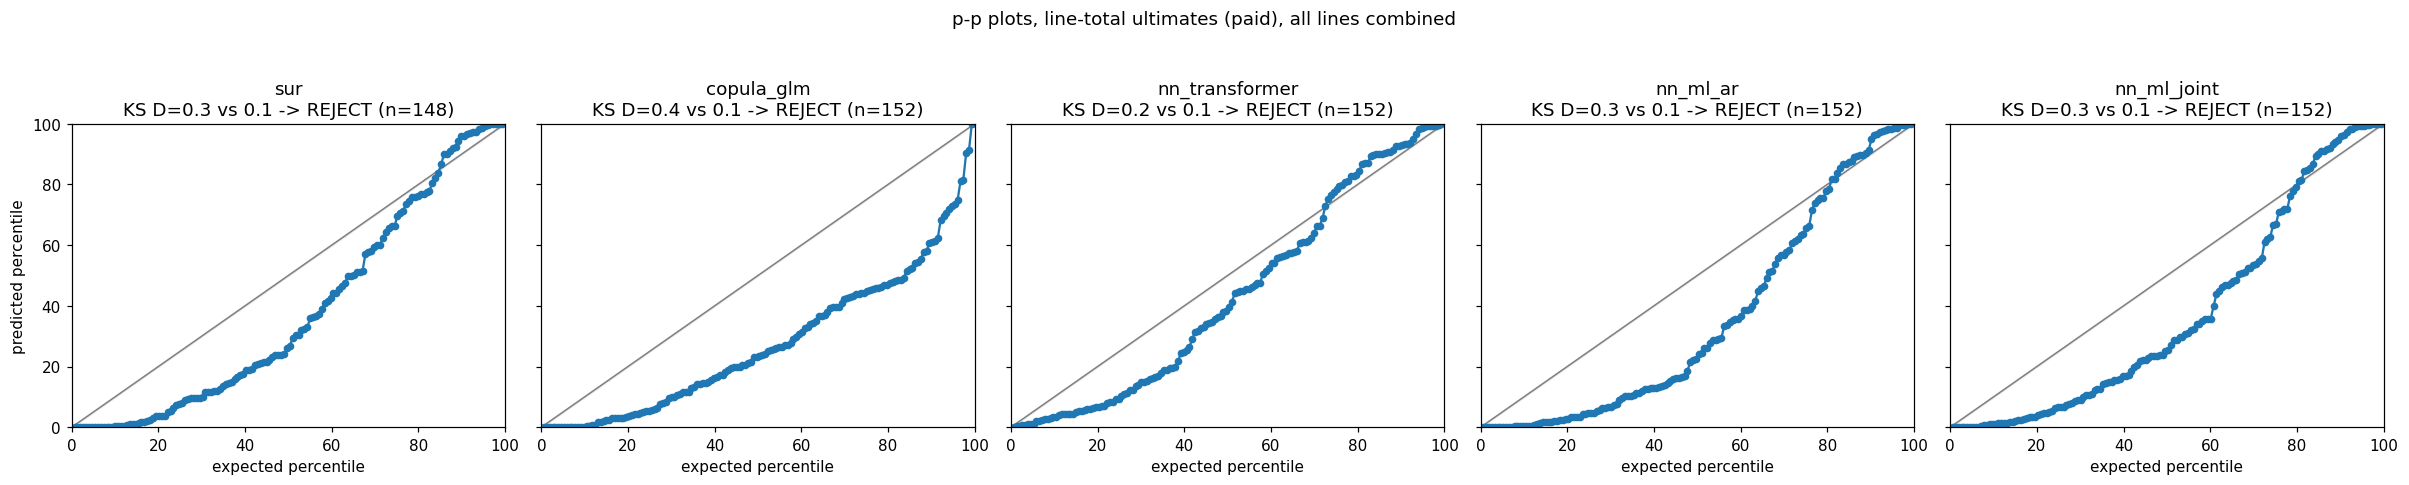

In [3]:
def pp_grid(data, models, suptitle):
    fig, axes = plt.subplots(1, len(models), figsize=(4.4 * len(models), 4.2), sharey=True)
    for ax, model in zip(axes, models):
        pcts = data.loc[data["model"] == model, "percentile"] / 100
        expected, predicted = pp_points(pcts)
        ks = ks_uniformity(pcts)
        band = ks.critical_value_5pct
        ax.plot([0, 100], [0, 100], color="grey", lw=1)
        ax.fill_between([0, 100], [-band, 100 - band], [band, 100 + band], alpha=0.15, color="grey")
        ax.plot(expected, predicted, "o-", ms=4)
        verdict = "REJECT" if ks.reject_5pct else "pass"
        ax.set_title(f"{model}\nKS D={ks.statistic:.1f} vs {band:.1f} -> {verdict} (n={ks.n})")
        ax.set_xlabel("expected percentile")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
    axes[0].set_ylabel("predicted percentile")
    fig.suptitle(suptitle, y=1.04)
    plt.tight_layout()
    plt.show()


pp_grid(ok, MODELS, "p-p plots, line-total ultimates (paid), all lines combined")

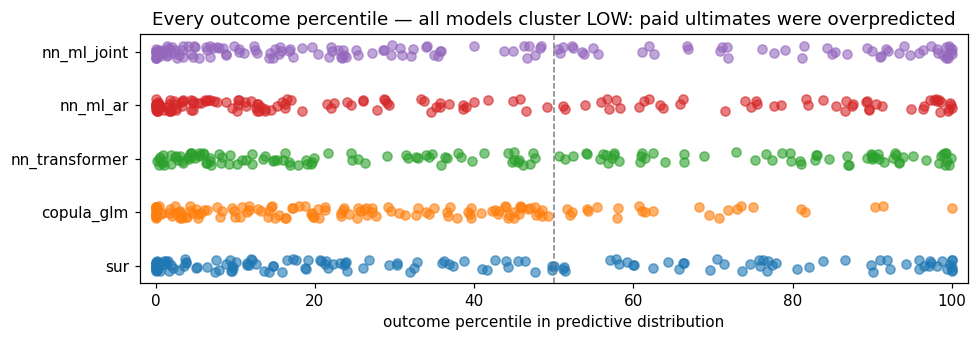

count  median  ks_d
model          line                                       
copula_glm     commercial_auto            49    24.2   0.4
               other_liability            30    17.9   0.4
               private_passenger_auto     41    19.5   0.4
               workers_compensation       32    36.9   0.2
nn_ml_ar       commercial_auto            49    38.6   0.1
               other_liability            30    28.9   0.3
               private_passenger_auto     41    12.7   0.4
               workers_compensation       32    12.3   0.5
nn_ml_joint    commercial_auto            49    35.0   0.2
               other_liability            30    26.5   0.3
               private_passenger_auto     41    15.0   0.4
               workers_compensation       32    24.5   0.3
nn_transformer commercial_auto            49    51.4   0.1
               other_liability            30    46.2   0.2
               private_passenger_auto     41    19.9   0.4
               workers_compensation       32    56.8   0.2
sur            commercial_auto            49    30.3   0.3
               other_liability            28    37.3   0.1
               private_passenger_auto     39    11.5   0.4
               workers_compensation       32    43.2   0.2

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, model in enumerate(MODELS):
    pcts = ok.loc[ok["model"] == model, "percentile"]
    ax.plot(
        pcts,
        np.full(len(pcts), i) + np.random.default_rng(0).uniform(-0.12, 0.12, len(pcts)),
        "o",
        alpha=0.6,
        label=model,
    )
ax.set_yticks(range(len(MODELS)), MODELS)
ax.set_xlabel("outcome percentile in predictive distribution")
ax.set_xlim(-2, 102)
ax.axvline(50, color="grey", lw=1, ls="--")
ax.set_title("Every outcome percentile — all models cluster LOW: paid ultimates were overpredicted")
plt.tight_layout()
plt.show()

per_line = (
    ok.groupby(["model", "line"])["percentile"]
    .agg(["count", "median"])
    .join(
        ok.groupby(["model", "line"])["percentile"]
        .apply(lambda p: ks_uniformity(p / 100).statistic)
        .rename("ks_d")
    )
    .round(1)
)
per_line

**Reading:** every model still fails the combined KS at n=152 with outcomes
piled low — the post-1997 favorable-development regime on paid Schedule P
(Meyers ch. 7 found the same for his paid models; it is why his headline
models use incurred). Within that shared handicap the ordering is now
clear: **nn_transformer is the best-calibrated paid model** (combined
D=18.3; passes commercial auto, other liability, AND workers comp
per-line — only PPA, the most regime-hit line, rejects), ahead of
sur (25.3), nn_ml_joint (25.4), nn_ml_ar (30.4) and copula_glm (35.1).
Robustness is its own finding at this scale: SUR failed outright on 2
companies (non-positive cumulative paid) and the copula produced divergent
fits on 7 of 152 cells (lognormal marginals exploding on small erratic
books — estimates up to 1e27); the transformers returned sane output on
all 152.

## Sharpness: CRPS

CRPS (lower = better) rewards distributions that are both calibrated and
tight, scaled by the outcome so lines and companies are comparable. The
chart uses the **median** per line: the copula's divergent fits make its
means meaningless (the table shows both — the 1e21 entries are those 7
blown cells, left visible deliberately).

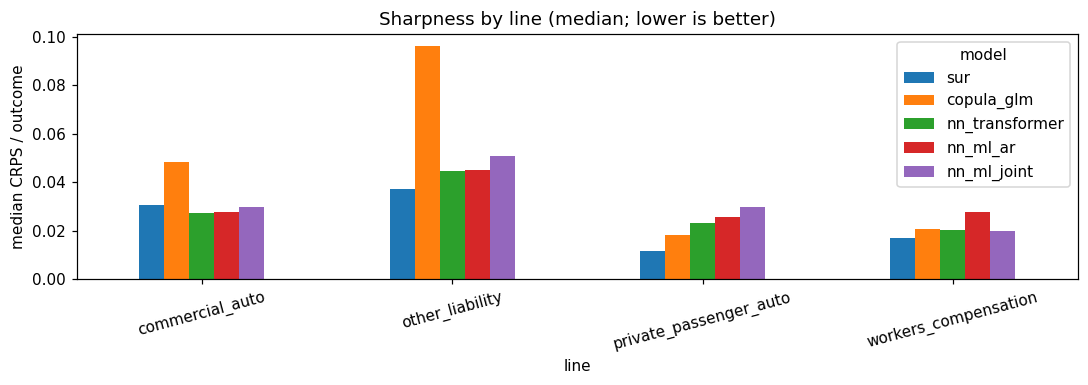

model,sur,copula_glm,nn_transformer,nn_ml_ar,nn_ml_joint
line,,,,,
commercial_auto,0.0305,0.0481,0.0273,0.0275,0.0297
other_liability,0.0371,0.0962,0.0448,0.0448,0.0509
private_passenger_auto,0.0114,0.0181,0.0231,0.0257,0.0298
workers_compensation,0.0167,0.0208,0.0204,0.0274,0.0198


model,sur,copula_glm,nn_transformer,nn_ml_ar,nn_ml_joint
line,,,,,
commercial_auto,0.0446,1.439604e+03,0.0343,0.0371,0.0422
other_liability,0.0547,2.199452e+21,0.0560,0.0587,0.0640
private_passenger_auto,0.0266,3.910000e-02,0.0266,0.0310,0.0331
workers_compensation,0.0368,5.820000e-02,0.0305,0.0382,0.0343


In [5]:
rel = ok.assign(rel_crps=ok["crps"] / ok["outcome"])
med = rel.pivot_table(index="line", columns="model", values="rel_crps", aggfunc="median")[MODELS]
axp = med.plot.bar(figsize=(10, 3.6), rot=15)
axp.set_ylabel("median CRPS / outcome")
axp.set_title("Sharpness by line (median; lower is better)")
plt.tight_layout()
plt.show()

mean = rel.pivot_table(index="line", columns="model", values="rel_crps", aggfunc="mean")[MODELS]
display(med.round(4))
mean.round(4)

## Bias

Signed ultimate error per (model, line, company). The plot clips at ±100%
so the copula's divergent cells don't flatten the axis (clipped count
printed).

clipped 12 cells with |err| > 100% (all copula_glm divergences)


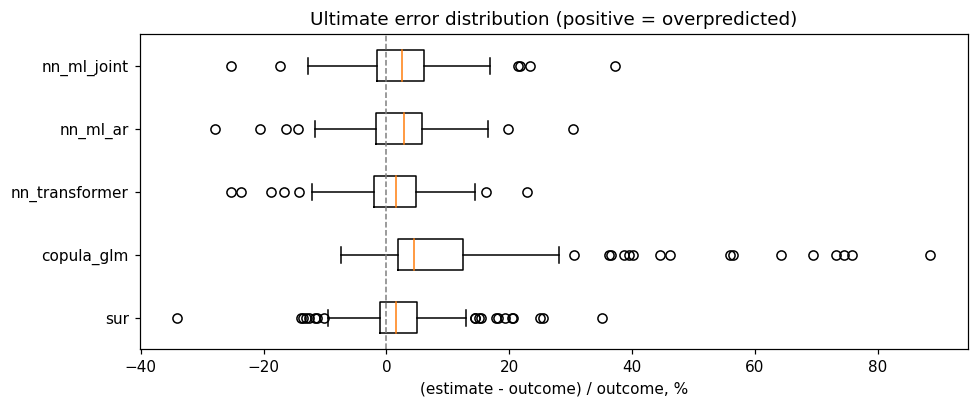

,count,mean,50%,min,max
model,,,,,
copula_glm,140.0,11.5,4.6,-7.3,88.5
nn_ml_ar,152.0,2.0,2.8,-27.9,30.4
nn_ml_joint,152.0,2.5,2.5,-25.4,37.2
nn_transformer,152.0,0.8,1.6,-25.3,22.9
sur,148.0,2.0,1.5,-34.1,35.1


In [6]:
plot_ok = ok[ok["err_pct"].abs() <= 100]
print(f"clipped {len(ok) - len(plot_ok)} cells with |err| > 100% (all copula_glm divergences)")
fig, ax = plt.subplots(figsize=(9, 3.8))
data = [plot_ok.loc[plot_ok["model"] == m, "err_pct"] for m in MODELS]
ax.boxplot(data, labels=MODELS, vert=False)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("(estimate - outcome) / outcome, %")
ax.set_title("Ultimate error distribution (positive = overpredicted)")
plt.tight_layout()
plt.show()
plot_ok.groupby("model")["err_pct"].describe().round(1)[["count", "mean", "50%", "min", "max"]]

## Point prediction: reserve-basis, distribution-free

The comparison Ethan asked for without distributions: predicted values
only, on the **reserve basis** — `est_reserve = estimate − anchor` vs
`actual_reserve = outcome − anchor`. Ultimate-basis errors flatter every
model for the paid-to-date it merely copies forward (a 3% ultimate error
on a short-tail line can be a 30% reserve error).

- **mae_prem_pct** — mean |reserve error| in points of premium (robust
  headline: actual reserves can sit near zero, which blows up APEs);
- **mdape_reserve** — median |reserve error| / |actual reserve|;
- **cl_skill** — raw MAE relative to volume-weighted chain ladder on the
  same cells (<1 beats the benchmark; raw MAE is big-company-weighted);
- **paired Wilcoxon** on |reserve error| — every model scores identical
  cells, so the paired design is the power we have.

In [7]:
def point_table(data, models):
    pt = data[data["estimate"].notna() & (data["line"] != "ALL")].copy()
    pt["res_est"] = pt["estimate"] - pt["anchor"]
    pt["res_act"] = pt["outcome"] - pt["anchor"]
    pt["abs_err"] = (pt["res_est"] - pt["res_act"]).abs()
    pt["err_prem_pct"] = (pt["res_est"] - pt["res_act"]) / pt["premium"] * 100
    with np.errstate(divide="ignore", invalid="ignore"):
        pt["res_ape"] = pt["abs_err"] / pt["res_act"].abs()
    agg = pt.groupby("model").agg(
        n=("abs_err", "size"),
        mae_prem_pct=("err_prem_pct", lambda s: s.abs().mean()),
        bias_prem_pct=("err_prem_pct", "mean"),
        mdape_reserve=("res_ape", "median"),
    )
    cells = pt.pivot_table(index=["line", "company_code"], columns="model", values="abs_err")
    agg["cl_skill"] = cells.mean() / cells["chain_ladder"].mean()
    wil = pd.DataFrame(index=models, columns=models, dtype=object)
    for a in models:
        for b in models:
            if a == b:
                wil.loc[a, b] = "-"
                continue
            pair = cells[[a, b]].dropna()
            d = pair[a] - pair[b]
            p = stats.wilcoxon(d).pvalue
            wil.loc[a, b] = f"{'<' if d.median() < 0 else '>'}{p:.3f}"
    return agg.loc[[m for m in models if m in agg.index]], wil


point_paid, wil_paid = point_table(df, POINT_MODELS)
display(point_paid.round(3))
print("paired Wilcoxon on |reserve error| (row vs col; '<' = row better):")
wil_paid

,n,mae_prem_pct,bias_prem_pct,mdape_reserve,cl_skill
model,,,,,
chain_ladder,152,3.294000e+00,1.259000e+00,0.203,1.000000e+00
sur,148,3.329000e+00,1.268000e+00,0.218,1.002000e+00
copula_glm,152,4.373353e+24,4.373353e+24,0.375,1.189720e+21
nn_transformer,152,3.003000e+00,3.730000e-01,0.253,1.939000e+00
nn_ml_ar,152,3.256000e+00,8.900000e-01,0.288,2.402000e+00
nn_ml_joint,152,3.384000e+00,1.076000e+00,0.278,2.720000e+00


paired Wilcoxon on |reserve error| (row vs col; '<' = row better):


,chain_ladder,sur,copula_glm,nn_transformer,nn_ml_ar,nn_ml_joint
chain_ladder,-,<0.789,<0.000,<0.091,<0.033,<0.030
sur,>0.789,-,<0.000,<0.209,<0.080,<0.066
copula_glm,>0.000,>0.000,-,>0.000,>0.001,>0.001
nn_transformer,>0.091,>0.209,<0.000,-,<0.037,<0.003
nn_ml_ar,>0.033,>0.080,<0.001,>0.037,-,<0.560
nn_ml_joint,>0.030,>0.066,<0.001,>0.003,>0.560,-


## Cross-line dependence: did attention carry it?

The manuscript's core question. For every multiline model, each company's
CSV rows contain the per-line total `se` AND the grand total's `se` from
the *same draws*, so two dependence diagnostics are recoverable from the
committed artifact alone:

- **diversification** = 1 − se(grand total) / Σ se(line totals) — how much
  the company-level distribution narrows relative to perfect dependence;
- **implied average correlation** of the line totals, from
  Var(total) = Σ Var_i + 2 Σ_{i<j} Cov_ij:
  ρ̄ = (se_ALL² − Σ se_i²) / (2 Σ_{i<j} se_i se_j).

`nn_transformer` has no ALL rows at all — its per-line draws are
independent by construction, which is exactly what the `nn_ml_*` entries
exist to fix.

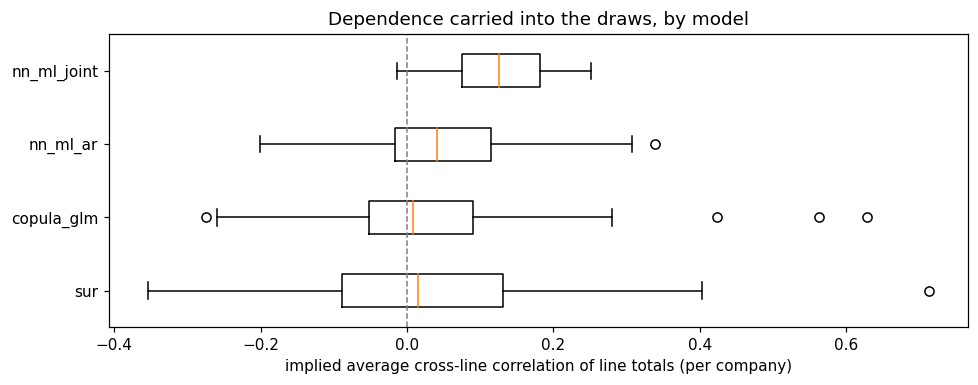

,n,implied_corr_median,diversification_median
sur,58.0,0.014,0.297
copula_glm,60.0,0.008,0.239
nn_ml_ar,60.0,0.041,0.243
nn_ml_joint,60.0,0.126,0.233


In [8]:
def dependence_stats(data, model):
    rows = []
    for code, grp in data[data["model"] == model].groupby("company_code"):
        lines_g = grp[grp["line"] != "ALL"]
        tot = grp[grp["line"] == "ALL"]
        if len(lines_g) < 2 or len(tot) != 1 or lines_g["se"].isna().any():
            continue
        se, se_all = lines_g["se"].to_numpy(), float(tot["se"].iloc[0])
        denom = 2 * sum(a * b for a, b in combinations(se, 2))
        if denom <= 0:
            continue
        rows.append(
            {
                "company_code": code,
                "rho": (se_all**2 - (se**2).sum()) / denom,
                "diversification": 1 - se_all / se.sum(),
            }
        )
    return pd.DataFrame(rows)


DEP_MODELS = ["sur", "copula_glm", "nn_ml_ar", "nn_ml_joint"]
dep = {m: dependence_stats(df, m) for m in DEP_MODELS}

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.boxplot([dep[m]["rho"].clip(-0.5, 1.0) for m in DEP_MODELS], labels=DEP_MODELS, vert=False)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("implied average cross-line correlation of line totals (per company)")
ax.set_title("Dependence carried into the draws, by model")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        m: {
            "n": len(dep[m]),
            "implied_corr_median": dep[m]["rho"].median(),
            "diversification_median": dep[m]["diversification"].median(),
        }
        for m in DEP_MODELS
    }
).T.round(3)

## Incurred (reported loss): the models on Meyers' home turf

The paid regime miss motivates the second field: **reported loss**
(incurred net of bulk+IBNR — the definition meyers_ccl was validated on).
Line-up changes:

- **meyers_ccl joins** — reported loss is its monograph-validated headline,
  the strongest available calibration yardstick;
- **copula_glm sits out** — incremental reported losses routinely go
  negative at late lags (case releases), which lognormal marginals cannot
  represent;
- all three transformers swap channels (reported as target, paid as
  feature).

Produced by `scripts/compare_gallery.py --loss-field reported_loss
--models sur nn_transformer nn_ml_ar nn_ml_joint meyers_ccl
--nn-features paid_loss`.

reported-loss run: 60 companies, 152 cells/model, publish 20260613_041006


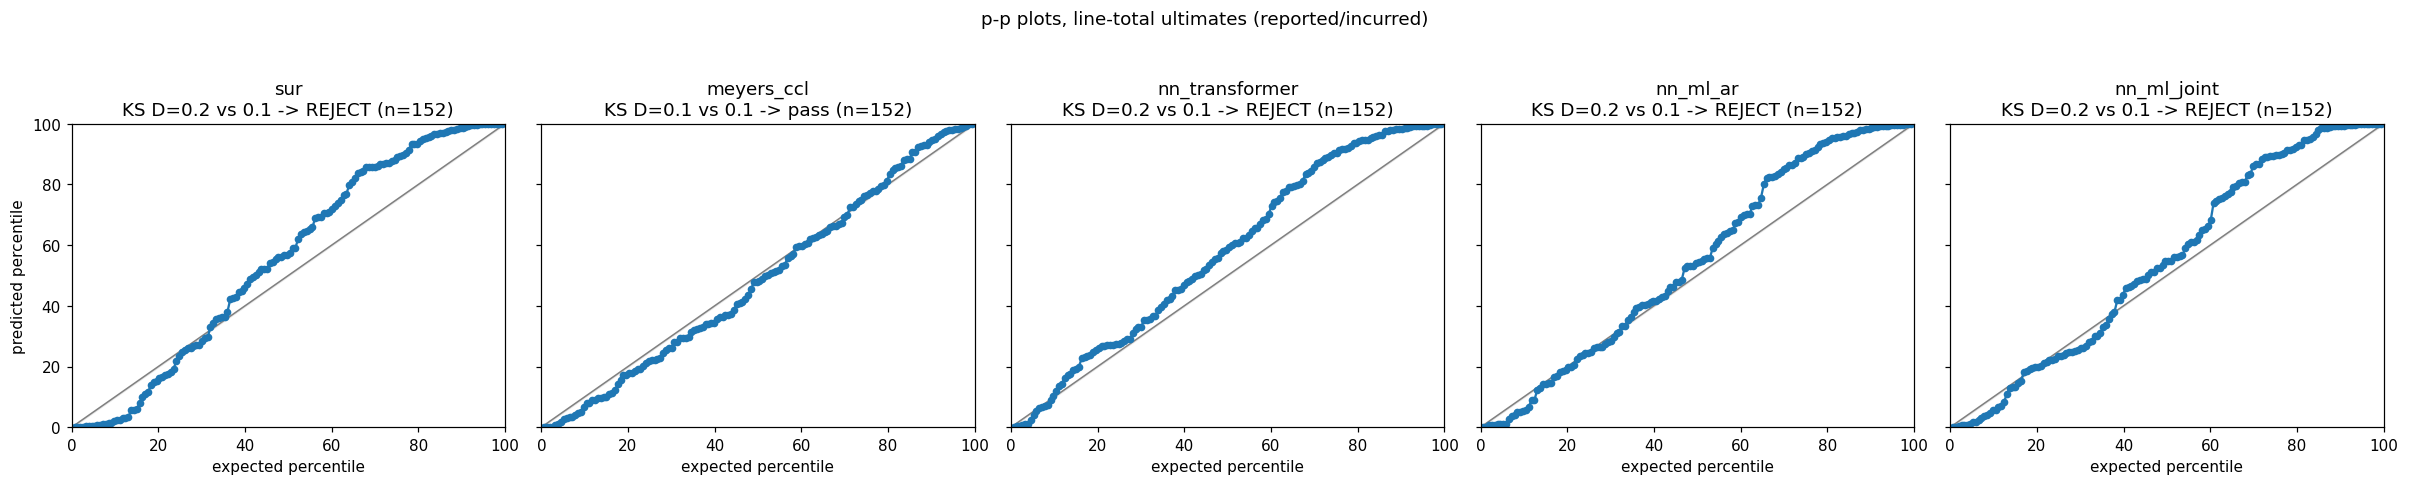

In [9]:
RESULTS_R = Path("results/compare_gallery_reported_loss.csv")
MODELS_R = ["sur", "meyers_ccl", "nn_transformer", "nn_ml_ar", "nn_ml_joint"]
ok_r, df_r = None, None
if RESULTS_R.exists():
    df_r = pd.read_csv(RESULTS_R, dtype={"company_code": str})
    ok_r = df_r[df_r["percentile"].notna() & (df_r["line"] != "ALL")].copy()
    ok_r["err_pct"] = (ok_r["estimate"] - ok_r["outcome"]) / ok_r["outcome"] * 100
    print(
        f"reported-loss run: {ok_r['company_code'].nunique()} companies, "
        f"{len(ok_r[ok_r['model'] == 'sur'])} cells/model, publish {df_r['mart_publish_id'].iloc[0]}"
    )
    pp_grid(ok_r, MODELS_R, "p-p plots, line-total ultimates (reported/incurred)")
else:
    print(f"{RESULTS_R} not found - run scripts/compare_gallery.py --loss-field reported_loss")

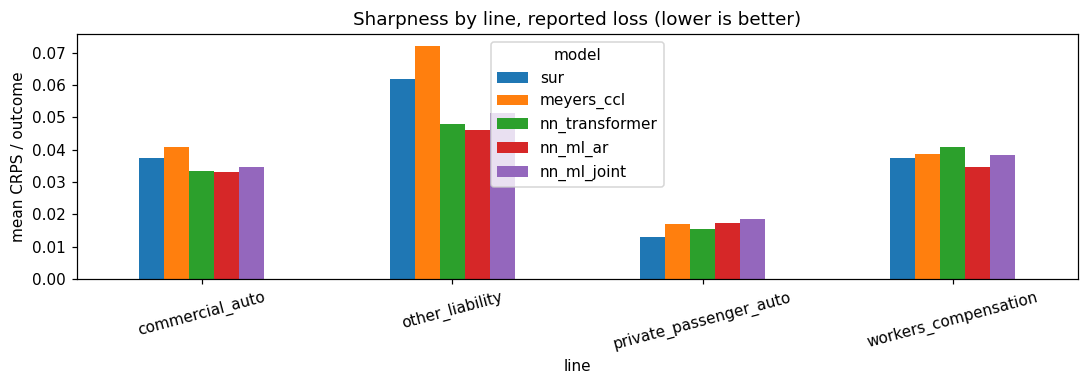

model,sur,meyers_ccl,nn_transformer,nn_ml_ar,nn_ml_joint
line,,,,,
commercial_auto,0.0374,0.0407,0.0335,0.0331,0.0346
other_liability,0.0619,0.0721,0.0479,0.0461,0.0514
private_passenger_auto,0.0130,0.0170,0.0154,0.0174,0.0186
workers_compensation,0.0375,0.0387,0.0409,0.0347,0.0384


,n,mae_prem_pct,bias_prem_pct,mdape_reserve,cl_skill
model,,,,,
chain_ladder,152,2.758,-0.189,0.627,1.000
sur,152,2.794,-0.131,0.644,1.015
meyers_ccl,152,3.356,0.734,0.701,1.461
nn_transformer,152,2.653,-0.853,0.617,1.811
nn_ml_ar,152,2.569,-0.530,0.581,1.253
nn_ml_joint,152,2.804,-0.512,0.635,2.563


paired Wilcoxon on |reserve error| (row vs col; '<' = row better):


,chain_ladder,sur,meyers_ccl,nn_transformer,nn_ml_ar,nn_ml_joint
chain_ladder,-,<0.365,<0.005,<0.018,<0.294,<0.091
sur,>0.365,-,<0.004,<0.024,<0.304,<0.134
meyers_ccl,>0.005,>0.004,-,>0.783,>0.638,>0.728
nn_transformer,>0.018,>0.024,<0.783,-,>0.093,<0.861
nn_ml_ar,>0.294,>0.304,<0.638,<0.093,-,<0.000
nn_ml_joint,>0.091,>0.134,<0.728,>0.861,>0.000,-


,implied_corr_median,diversification_median
sur,0.019,0.243
nn_ml_ar,0.047,0.238
nn_ml_joint,0.079,0.234


In [10]:
if ok_r is not None:
    rel_r = ok_r.assign(rel_crps=ok_r["crps"] / ok_r["outcome"])
    pivot_r = rel_r.pivot_table(index="line", columns="model", values="rel_crps", aggfunc="mean")
    axp = pivot_r[MODELS_R].plot.bar(figsize=(10, 3.6), rot=15)
    axp.set_ylabel("mean CRPS / outcome")
    axp.set_title("Sharpness by line, reported loss (lower is better)")
    plt.tight_layout()
    plt.show()
    display(pivot_r[MODELS_R].round(4))

    point_rep, wil_rep = point_table(df_r, ["chain_ladder", *MODELS_R])
    display(point_rep.round(3))
    print("paired Wilcoxon on |reserve error| (row vs col; '<' = row better):")
    display(wil_rep)

    dep_r = {m: dependence_stats(df_r, m) for m in ["sur", "nn_ml_ar", "nn_ml_joint"]}
    display(
        pd.DataFrame(
            {
                m: {
                    "implied_corr_median": d["rho"].median(),
                    "diversification_median": d["diversification"].median(),
                }
                for m, d in dep_r.items()
            }
        ).T.round(3)
    )

### Paid vs incurred, side by side

The same summary statistics for both fields — combined KS distance,
5% verdict, mean CRPS/outcome, and mean signed reserve error.

In [11]:
def field_summary(data, field_name):
    rows = []
    for model, grp in data.groupby("model"):
        ks = ks_uniformity(grp["percentile"] / 100)
        rows.append(
            {
                "field": field_name,
                "model": model,
                "n": len(grp),
                "ks_d": round(ks.statistic, 1),
                "ks_5pct": "REJECT" if ks.reject_5pct else "pass",
                "mean_rel_crps": round((grp["crps"] / grp["outcome"]).mean(), 4),
                "mean_err_pct": round(grp["err_pct"].mean(), 1),
            }
        )
    return pd.DataFrame(rows)


summary = field_summary(ok, "paid")
if ok_r is not None:
    summary = pd.concat([summary, field_summary(ok_r, "reported")], ignore_index=True)
summary.sort_values(["field", "mean_rel_crps"]).reset_index(drop=True)

,field,model,n,ks_d,ks_5pct,mean_rel_crps,mean_err_pct
0,paid,nn_transformer,152,0.2,REJECT,3.570000e-02,8.000000e-01
1,paid,nn_ml_ar,152,0.3,REJECT,4.000000e-02,2.000000e+00
2,paid,sur,148,0.3,REJECT,4.010000e-02,2.000000e+00
3,paid,nn_ml_joint,152,0.3,REJECT,4.240000e-02,2.500000e+00
4,paid,copula_glm,152,0.4,REJECT,4.341023e+20,9.947235e+24
5,reported,nn_ml_ar,152,0.2,REJECT,3.180000e-02,-4.000000e-01
6,reported,nn_transformer,152,0.2,REJECT,3.300000e-02,-1.200000e+00
7,reported,nn_ml_joint,152,0.2,REJECT,3.440000e-02,-3.000000e-01
8,reported,sur,152,0.2,REJECT,3.570000e-02,-1.000000e-01
9,reported,meyers_ccl,152,0.1,pass,4.010000e-02,1.600000e+00


## Deep dive: dependence estimates and diversification (one company)

The point of the multiline models is the cross-line dependence. Refit both
statistical models on one company (fits are sub-second) and inspect what they
actually estimated, and what it does to the grand-total distribution.

In [12]:
import ibis

from ibnr import gallery
from ibnr.data.schedule_p import active_publish_id, load_schedule_p

# standard resolution: IBNR_SCHEDULE_P_WAREHOUSE env var, else the newest
# GitHub release of the data repo (downloaded once into ~/.cache/ibnr)
SOURCE = None
AS_OF = "1997-12-31"
print("reading gold publish:", active_publish_id(SOURCE))

# a company scored on all four lines (deep-dive only uses its SCREENED
# lines — unscreened lines can carry non-positive paid cells SUR rejects)
sur_ok = ok[ok["model"] == "sur"]
by_code = sur_ok.groupby("company_code")["line"].apply(list)
CODE = by_code[by_code.str.len() == by_code.str.len().max()].index[0]
CODE_LINES = sorted(by_code[CODE])

tri = load_schedule_p(SOURCE, lines=CODE_LINES).filter(ibis._.company_code == CODE)
sur = gallery.fit("sur", tri, loss_field="paid_loss", as_of=AS_OF)
try:
    cop = gallery.fit("copula_glm", tri, loss_field="paid_loss", as_of=AS_OF, nonpositive="drop")
except ValueError:  # dropped cells can deplete late dev factor effects
    cop = gallery.fit(
        "copula_glm",
        tri,
        loss_field="paid_loss",
        as_of=AS_OF,
        nonpositive="drop",
        dev_effect="hoerl",
    )
print(
    f"company {CODE} ({len(CODE_LINES)} lines): "
    f"SUR transition methods -> {[t['method'] for t in sur.transitions_]}"
)

reading gold publish: 20260613_041006


company 14176 (4 lines): SUR transition methods -> ['fgls', 'fgls', 'fgls', 'fgls', 'pooled_corr', 'pooled_corr', 'pooled_corr', 'tail', 'tail']


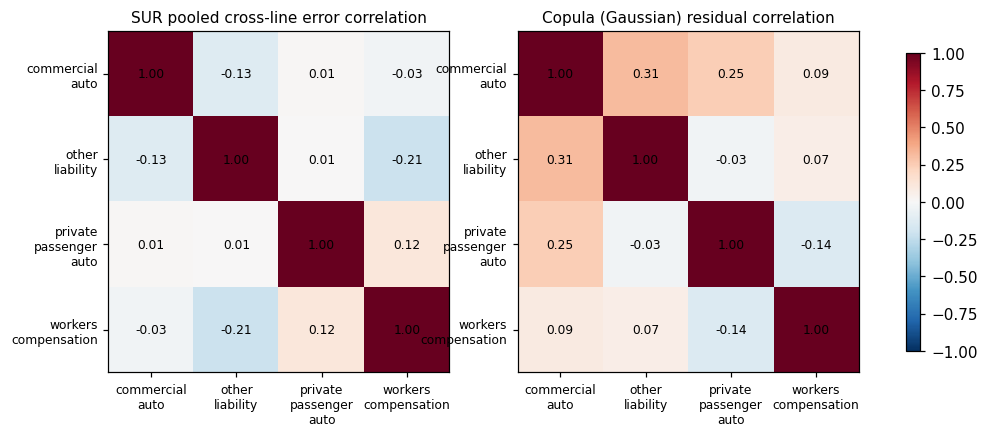

In [13]:
lobs = sur.contract_["lobs"]
short = [lob.replace("_", "\n") for lob in lobs]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mat, title) in zip(
    axes,
    [
        (sur.pooled_corr_, "SUR pooled cross-line error correlation"),
        (cop.corr_, "Copula (Gaussian) residual correlation"),
    ],
):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(lobs)), short, fontsize=8)
    ax.set_yticks(range(len(lobs)), short, fontsize=8)
    for i in range(len(lobs)):
        for j in range(len(lobs)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

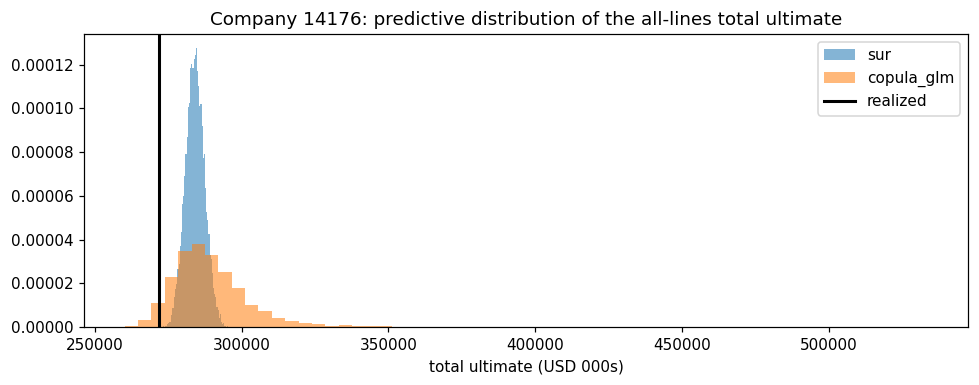

,sum of per-line sd,grand-total sd,implied diversification
sur,6577.518,3242.527,0.507
copula_glm,22184.139,14619.565,0.341


In [14]:
pred_sur = sur.predict(n_draws=10_000, seed=0)
pred_cop = cop.predict(n_draws=10_000, seed=0)
realized = sur.realized_ultimates(tri)

n_cells = len(lobs) * sur.contract_["n_w"]
per_lob_sd_sur = pred_sur.std()[n_cells : n_cells + len(lobs)]
per_lob_sd_cop = pred_cop.std()[n_cells : n_cells + len(lobs)]
div = pd.DataFrame(
    {
        "sum of per-line sd": [per_lob_sd_sur.sum(), per_lob_sd_cop.sum()],
        "grand-total sd": [pred_sur.std()[-1], pred_cop.std()[-1]],
    },
    index=["sur", "copula_glm"],
)
div["implied diversification"] = 1 - div["grand-total sd"] / div["sum of per-line sd"]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(pred_sur.samples[:, -1], bins=60, alpha=0.55, density=True, label="sur")
ax.hist(pred_cop.samples[:, -1], bins=60, alpha=0.55, density=True, label="copula_glm")
ax.axvline(realized[-1], color="black", lw=2, label="realized")
ax.set_title(f"Company {CODE}: predictive distribution of the all-lines total ultimate")
ax.set_xlabel("total ultimate (USD 000s)")
ax.legend()
plt.tight_layout()
plt.show()
div.round(3)

Positive cross-line correlation means the grand-total sd shrinks *less*
than independence would imply — the single-company view of the same
diagnostics computed market-wide above.

## Findings (widened study, n=152 cells, 60 companies)

**Calibration (paid).** Everyone rejects the combined KS — the post-1997
favorable-development regime — but the ordering is informative:
nn_transformer D=18.3 (passes 3 of 4 lines) < sur 25.3 ≈ nn_ml_joint 25.4 <
nn_ml_ar 30.4 < copula 35.1. **Calibration (reported):** meyers_ccl passes
outright (D=6.7, p=0.50 — consistent with its 200-company validation);
all others reject at D≈16-18, driven entirely by workers comp.

**Sharpness.** Paid (median rel-CRPS): nn_transformer best or tied on
every line. Reported: nn_ml_ar wins commercial auto (0.033), other
liability (0.046) and workers comp (0.035); sur keeps only PPA (0.013).
The single-line transformer remains marginally sharper than the ML
variants per line — attention across lines costs a little marginal
accuracy and buys the joint distribution the single-line model cannot
produce at all.

**Point prediction (reserve basis).** The sobering result: volume-weighted
chain ladder is genuinely hard to beat on point reserves. Paid: CL MdAPE
0.203, sur 0.218 (skill 1.002, p=0.79 — SUR *is* refined CL); every
transformer trails CL on raw MAE (skill 1.9-2.7, big-company misses),
though nn_transformer has the best premium-normalized MAE (3.00) and the
least bias (+0.4 points of premium). Reported: **nn_ml_ar beats CL on
premium-normalized MAE (2.57 vs 2.76) and MdAPE (0.58 vs 0.63)** (paired
p=0.29, not significant), while meyers_ccl is significantly *worse* than
nn_transformer and sur on points (p≈0.005) despite winning calibration —
the classic sharpness/calibration trade laid bare.

**Dependence (the research question).** Both mechanisms carry cross-line
dependence into the draws, and both carry MORE than the classical
dependence models: median implied line-total correlation 0.13 (nn_ml_joint,
paid) / 0.08 (reported) and 0.04-0.05 (nn_ml_ar) vs 0.01-0.02 for SUR and
0.01 for the copula. The explicit covariance head carries the most, as
designed; the AR head confirms attention + feedback transmits dependence
through conditioning alone. Diversification medians all land in a
plausible 0.23-0.30 band.

**AR vs joint.** AR is the better default: on reported it beats joint
decisively on paired point errors (p<0.001) and is sharper on 3 of 4
lines; joint's edge is paid calibration (25.4 vs 30.4) and the richest
dependence. Joint's L(L+1)/2 covariance parameters per component are the
overfitting frontier its card warned about.

**Robustness.** At n=152 the classical models crack where the transformers
do not: sur failed 2 companies outright (non-positive cumulative paid),
copula_glm diverged on 7 cells (estimates to 1e27). The transformers
returned sane output on all 152 — pooling across companies is regularity
the per-company fits don't have.

**Scoreboard by use-case:** distributional reserving on incurred →
meyers_ccl for calibration, nn_ml_ar for sharpness + coherent company
totals; paid → nn_transformer; point reserves → chain ladder / SUR remain
the benchmark to beat, with nn_ml_ar the first ML entry to edge CL on a
premium-normalized basis.

**Caveats & next.** One train/test window (1988-1997 → runoff): the paid
KS rejections are a regime finding, not model rankings; multi-window
backtests need milestone-5 machinery. The transformers' remaining
weaknesses: PPA calibration on paid, WC on reported, big-company raw MAE —
exposure-aware sigma is the obvious next lever, then HPO
(`kernels/tuning.py`). Reruns:
`uv run python scripts/compare_gallery.py --models sur copula_glm
nn_transformer nn_ml_ar nn_ml_joint` (paid, ~2h) and
`--loss-field reported_loss --models sur nn_transformer nn_ml_ar
nn_ml_joint meyers_ccl --nn-features paid_loss` (~2h).